# Evaluación Final del Modelo

Este notebook da continuidad al proceso de entrenamiento y ajuste de hiperparámetros realizado previamente. Como se concluyó en la etapa de modelado, tras evaluar distintas arquitecturas de la familia YOLOv26, el modelo seleccionado por su excelente balance y métricas top (especialmente su desempeño en mAP50-95 con un 85.9%) fue la **variante medium (`yolo26m`)**.

A continuación, procederemos a cargar los mejores pesos obtenidos durante su entrenamiento (`best.pt`) para evaluar formalmente su capacidad de generalización sobre un conjunto de datos completamente nuevo y no visto durante el entrenamiento o la validación: el **conjunto de Test**.

In [3]:
from ultralytics import YOLO

best_weights_path = '../training/runs/train/26m/yolo_vertex_exp-7/weights/best.pt'
data_cfg = '../../data/processed/data.yml'

model = YOLO(best_weights_path)

In [ ]:
results_test = model.val(data=data_cfg,split="test")

Ultralytics 8.4.55 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA L4, 22563MiB)
YOLO26m summary (fused): 132 layers, 20,367,956 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 93.3±99.3 MB/s, size: 175.5 KB)
val: Scanning /content/data/processed/test/labels... 750 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 750/750 881.1it/s 0.9s
val: /content/data/processed/test/images/1050922.jpg: corrupt JPEG restored and saved
val: /content/data/processed/test/images/1052052.jpg: corrupt JPEG restored and saved
val: /content/data/processed/test/images/1052751.jpg: corrupt JPEG restored and saved
val: /content/data/processed/test/images/1054563.jpg: corrupt JPEG restored and saved
val: /content/data/processed/test/images/1056312.jpg: corrupt JPEG restored and saved
val: /content/data/processed/test/images/1056462.jpg: corrupt JPEG restored and saved
val: New cache created: /content/data/processed/test/labels.cache
                 Class     Images  

### Visualización de Resultados en Conjunto de Test
A continuación podemos visualizar los resultados obtenidos por nuestro modelo óptimo (`yolo26m`) al evaluarse sobre el conjunto de imágenes de *Test*.

#### Matriz de Confusión Normalizada
![Matriz de Confusión Normalizada Test](runs/test/confusion_matrix_normalized.png)

Al ser evaluado frente a datos que el modelo jamás ha visto, la matriz de confusión normalizada (y su diagonal principal) nos da la imagen más realista del desempeño final en un escenario de producción. Observamos el grado de acierto por clase y confirmamos si las características aprendidas en entrenamiento/validación generalizan correctamente al conjunto de prueba, o si existe confusión recurrente con determinadas clases y el fondo (Background).

#### Curva Precision-Recall
![Curva Precision-Recall Test](runs/test/BoxPR_curve.png)

Adicionalmente, podemos revisar la curva de Precision-Recall para las cajas delimitadoras (*Bounding Boxes*). Una curva que asciende alto y se mantiene cercana a la esquina superior derecha denota un rendimiento excepcional, combinando una baja tasa de falsos positivos y una alta capacidad de recuperación (Recall).

In [ ]:
print(results_test.results_dict)

{'metrics/precision(B)': 0.9700733433827681, 'metrics/recall(B)': 0.9646033546340934, 'metrics/mAP50(B)': 0.9900387600980302, 'metrics/mAP50-95(B)': 0.8598890151877351, 'fitness': 0.8598890151877351}


---

Los resultados numéricos arrojados por la evaluación final (`model.val(split="test")`) confirman la robustez del modelo `yolo26m` frente a datos no vistos:

*   **Precision:** 97.01%
*   **Recall:** 96.46%
*   **mAP50:** 99.00%
*   **mAP50-95:** 85.99%

**Conclusión:**
Al comparar estas métricas con las obtenidas durante la fase de validación (donde rondábamos los 85.9% de mAP50-95 y 99% de mAP50), notamos que los valores se conservan de forma casi idéntica. Esto es una noticia excelente, pues significa que **no hay sobreajuste (overfitting)** en nuestra red neuronal; el modelo generaliza ante escenarios y objetos completamente nuevos. 

La exigencia clave de este proyecto –el desempeño en el umbral **mAP50-95**– se encuentra en un sólido **casi 86%**, lo cual garantiza detecciones sumamente precisas a nivel espacial (Bounding Boxes bien ajustadas). 

### Inferencia Manual sobre Imágenes de Test

Podemos alimentar a nuestro modelo cargado (`yolo26m`) con imágenes sueltas o una lista de imágenes de Test, para generar las inferencias y analizar cómo dibuja (*plotea*) los *bounding boxes* el modelo directamente. respecto a las imágenes de referencia

Haciendo inferencia sobre: ['103094.jpg', '103112.jpg']

0: 640x640 2 A1s, 2 A2s, 2 A3s, 2 B4s, 2 B5s, 2 C10s, 2 C11s, 2 C12s, 3 C6s, 2 C7s, 2 C8s, 2 C9s, 2 D13s, 2 D14s, 2 D15s, 2 E16s, 2 E17s, 2 E18s, 2 F19s, 2 F20s, 2 G21s, 2 G22s, 1 X, 1 Y, 225.3ms
1: 640x640 2 A1s, 2 A2s, 2 A3s, 2 B4s, 2 B5s, 2 C10s, 2 C11s, 2 C12s, 3 C6s, 3 C7s, 2 C8s, 2 C9s, 2 D13s, 2 D14s, 3 D15s, 1 E16, 2 E17s, 2 E18s, 2 F19s, 2 F20s, 3 G21s, 3 G22s, 2 Xs, 225.3ms
Speed: 9.3ms preprocess, 225.3ms inference, 0.1ms postprocess per image at shape (1, 3, 640, 640)


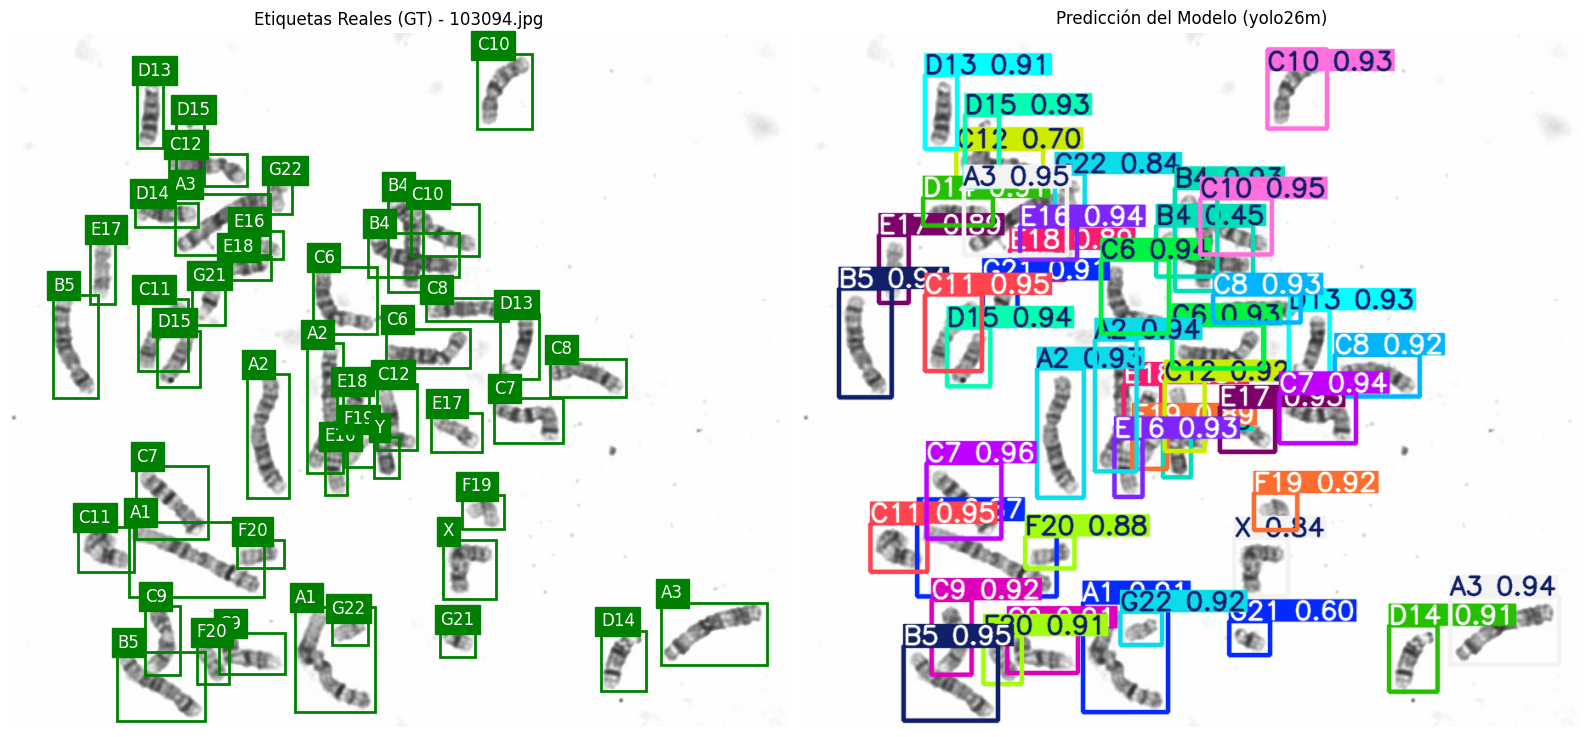

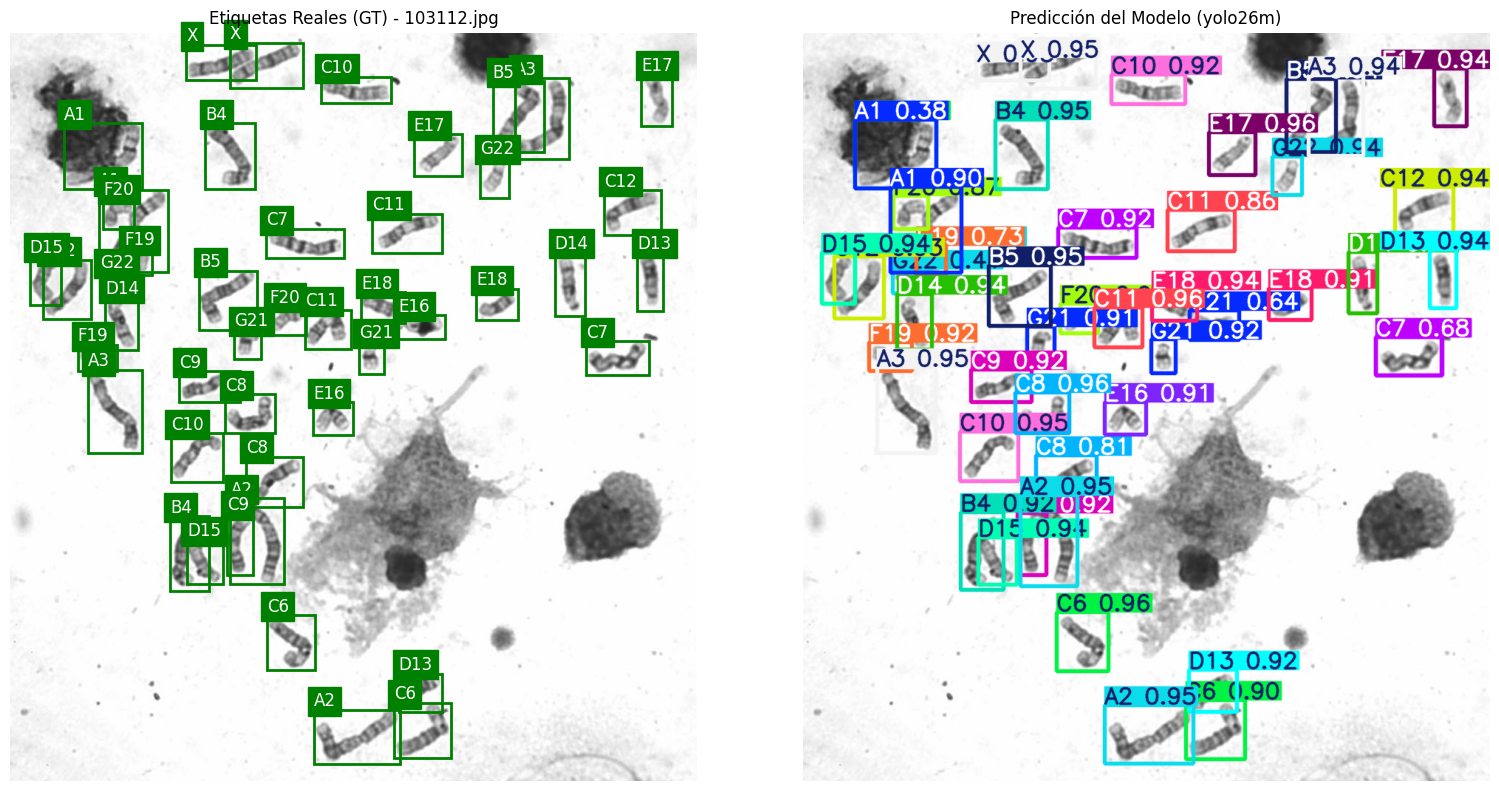

In [ ]:
import os
import glob
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

test_images_dir = '../../data/processed/test/images/'
test_labels_dir = '../../data/processed/test/labels/'

test_images = glob.glob(os.path.join(test_images_dir, '*.jpg'))[:2]

if not test_images:
    print("No se encontraron imágenes en el directorio de test.")
else:
    print(f"Haciendo inferencia sobre: {[os.path.basename(img) for img in test_images]}")
    
    results = model(test_images)

    for i, result in enumerate(results):
        img_path = test_images[i]
        img_name = os.path.basename(img_path)
        label_path = os.path.join(test_labels_dir, img_name.replace('.jpg', '.txt'))
        
        fig, axes = plt.subplots(1, 2, figsize=(16, 8))
        
        img_gt = Image.open(img_path)
        w, h = img_gt.size
        axes[0].imshow(img_gt)
        axes[0].set_title(f"Etiquetas Reales (GT) - {img_name}")
        axes[0].axis('off')
        
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f.readlines():
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        cls_id = int(parts[0])
                        x_center, y_center, bw, bh = map(float, parts[1:5])
                        
                        abs_x = (x_center - bw / 2) * w
                        abs_y = (y_center - bh / 2) * h
                        abs_w = bw * w
                        abs_h = bh * h
                        
                        rect = patches.Rectangle((abs_x, abs_y), abs_w, abs_h, 
                                                 linewidth=2, edgecolor='green', facecolor='none')
                        axes[0].add_patch(rect)
                        
                        class_name = model.names.get(cls_id, str(cls_id))
                        axes[0].text(abs_x, abs_y - 5, class_name, 
                                     color='white', fontsize=12, backgroundcolor='green')
        else:
            axes[0].text(10, 30, "Sin etiquetas (Background)", color='white', backgroundcolor='red')

        img_pred = result.plot()
        axes[1].imshow(img_pred[..., ::-1])  # Convertir de BGR a RGB
        axes[1].set_title(f"Predicción del Modelo (yolo26m)")
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()